# Data Preprocessing

Data visualization, preprocessing, and normalization

## Resample the data and derive velocity and acceleration

The fpv-uzh and mid-air datasets have different sample rates and formats. This code is meant to resample everything to 10hz (sample time = 0.1sec). It does this via block means as a simple noise reduction method. More sophisticated noise reduction techniques need to be explored later.

The sample rate is can actually be thought of as a hyperparameter for our model. For now, we are following the VECTOR GRU paper.

The model can either be trained on positional, velocity, or acceleration data.

At the moment, the acceleration data seems to be too noisy to be useful.

In [1]:
from src.preprocessing import walk_and_process


data_root = "data/clean"
pos_path = "data/position/raw"
vel_path = "data/velocity/raw" 
acc_path = "data/acceleration/raw"

walk_and_process(
    root=data_root,
    out_path_pos=pos_path,
    out_path_vel=vel_path,
    out_path_acc=acc_path,
)

## Data Normalization

Computes the global L2 norm and normalizes data against it.

In [2]:

from src.preprocessing import walk_and_normalize

data_root = "data/clean"
pos_path = "data/position/raw"
vel_path = "data/velocity/raw" 
acc_path = "data/acceleration/raw"

pos_norm_path = "data/position/max_norm"
walk_and_normalize(
    root=pos_path,
    out=pos_norm_path,
    coords=["tx", "ty", "tz"]
)

vel_norm_path = "data/velocity/max_norm"
walk_and_normalize(
    root=vel_path,
    out=vel_norm_path,
    coords=["vx", "vy", "vz"]
)

acc_norm_path = "data/acceleration/max_norm"
walk_and_normalize(
    root=acc_path,
    out=acc_norm_path,
    coords=["ax", "ay", "az"]
)

# K-fold Cross validation

Code to generate 5 folds with training, testing, and validation sets and saves as json file.

This way we have "global access" to the folds, and the jobs we queue can independently work on a fold.

In [4]:
from src.datasets import Split, generate_split, save_split

root="data/velocity/max_norm"
folds: Split = generate_split(
    root=root, 
    k = 5, 
    shuffle = False
)

output_file = "data/folds.json"
save_split(folds, output_file)

## Interactive path visualization

This code assumes you have `position`, `velocity`, and `acceleration` directories, and that the columns are formatted correctly.

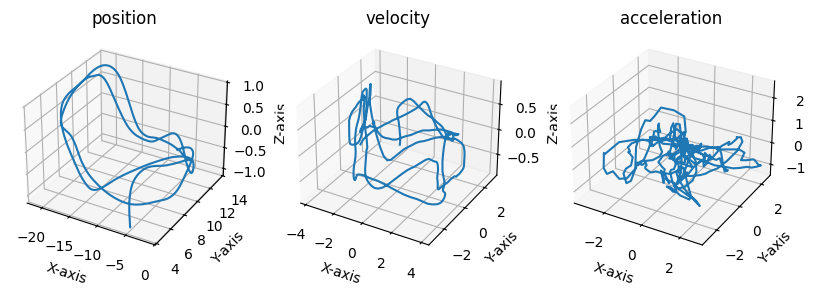

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib inline

coords = {
    "position": ["tx", "ty", "tz"],
    "velocity": ["vx", "vy", "vz"],
    "acceleration": ["ax", "ay", "az"],
}

coord_types = list(coords.keys())

def create_interactive_3d_plot(norm="raw"):
    root = "./data"
    # Just start out with position
    dirs = os.listdir(os.path.join(root, coord_types[0], norm))

    directory_dropdown = widgets.Dropdown(
        options=dirs,
        description="Select Directory:",
        disabled=False
    )

    # Get a list of all CSV files in the specified directory
    csv_files = os.listdir(os.path.join(root, coord_types[0], norm, dirs[0]))
    if not csv_files:
        print(f"No CSV files found in {os.path.abspath(root)}")
        return

    # Create a dropdown widget for file selection
    file_dropdown = widgets.Dropdown(
        options=csv_files,
        description="Select CSV:",
        disabled=False,
    )

    output_area = widgets.Output()

    fig = plt.figure(figsize=(10, 8))
    axs = {
        "position": fig.add_subplot(131, projection="3d"),
        "velocity": fig.add_subplot(132, projection="3d"),
        "acceleration": fig.add_subplot(133, projection="3d"),
    }

    def update_files(change):
        with output_area:
            clear_output(wait=True)
            selected_directory = change["new"]
            new_files = os.listdir(os.path.join(root, coord_types[0], norm, selected_directory))

            if new_files:
                file_dropdown.options = new_files
                file_dropdown.disabled = False
            else:
                file_dropdown.options = ["No files"]
                file_dropdown.disabled = True

    def update_plot(change):
        with output_area:
            clear_output(wait=True)
            selected_file = change["new"]
            selected_directory = directory_dropdown.value
            
            for c in coord_types:
                file_path = os.path.join(root, c, norm, selected_directory, selected_file)
                ax = axs[c]
                ax.clear()
                
                try:
                    df = pd.read_csv(file_path)
                    x, y, z = coords [c]
                    if x not in df.columns or y not in df.columns or z not in df.columns:
                        ax.clear() # Clear any previous plot or error message
                        ax.text2D(0.5, 0.5, f"Error: '{file_path}' missing '{x}', '{y}', or '{z}' columns.", # type: ignore
                                transform=ax.transAxes, ha="center")
                        fig.canvas.draw_idle()
                        return

                    ax.clear()

                    line = ax.plot(df[x], df[y], df[z])[0]

                    # Update labels and title
                    ax.set_xlabel("X-axis")
                    ax.set_ylabel("Y-axis")
                    ax.set_zlabel("Z-axis") # type: ignore
                    ax.set_title(c)

                    # Ensure data limits are set correctly for the new data
                    x_min, x_max = df[x].min(), df[x].max()
                    y_min, y_max = df[y].min(), df[y].max()
                    z_min, z_max = df[z].min(), df[z].max()

                    # Add a small buffer to the limits for better visualization
                    x_buffer = (x_max - x_min) * 0.05
                    y_buffer = (y_max - y_min) * 0.05
                    z_buffer = (z_max - z_min) * 0.05

                    ax.set_xlim(x_min - x_buffer, x_max + x_buffer)
                    ax.set_ylim(y_min - y_buffer, y_max + y_buffer)
                    ax.set_zlim(z_min - z_buffer, z_max + z_buffer) # type: ignore

                    
                except Exception as e:
                    ax.clear() # Clear any previous plot or error message
                    ax.text2D(0.5, 0.5, f"Error loading or plotting {file_path}: {e}", # type: ignore
                            transform=ax.transAxes, ha="center")
                    fig.canvas.draw_idle()


    directory_dropdown.observe(update_files, names="value")
    file_dropdown.observe(update_plot, names="value")

    display(widgets.VBox([directory_dropdown, file_dropdown, output_area]))

    update_files({"new": directory_dropdown.value})
    update_plot({"new": file_dropdown.value})
    
    plt.show()

create_interactive_3d_plot("raw")

In [ ]:
from src.datasets import generate_split, save_split

root = "data/velocity/max_norm"
folds = generate_split(root=root, k=5, shuffle=False)
save_split(folds, "data/folds.json")
print("saved split to data/folds.json")